In [ ]:
import os

REPO_URL  = "https://github.com/MANAL2288/computer-vision-project.git"
REPO_NAME = "computer-vision-project"

# Force re-clone to get latest version
os.system(f"rm -rf /content/{REPO_NAME}")
os.system(f"git clone {REPO_URL} /content/{REPO_NAME}")
print("Repository cloned!")

DATA_DIR   = f"/content/{REPO_NAME}/data"
OUTPUT_DIR = f"/content/{REPO_NAME}/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

images = [f for f in os.listdir(DATA_DIR) if f.endswith(('.png','.jpg','.jpeg'))]
print(f"Images found: {len(images)}")

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MANAL2288/computer-vision-project/blob/main/code/project3-barcode-qr-scanner.ipynb)

# 📷 Barcode & QR Code Scanner and Localizer

<div style="display:flex; justify-content:space-between; align-items:center;">
    <div>
        <p style="font-size:20px; margin:5px 0;">
            <b>Course:</b> Introduction to Computer Vision
        </p>
        <p style="font-size:20px; margin:5px 0;">
            <b>Institution:</b> ESIN, UIR — Spring 2026
        </p>
        <p style="font-size:20px; margin:5px 0;">
            <b>Instructor:</b> Ilias TOUGUI
        </p>
    </div>
    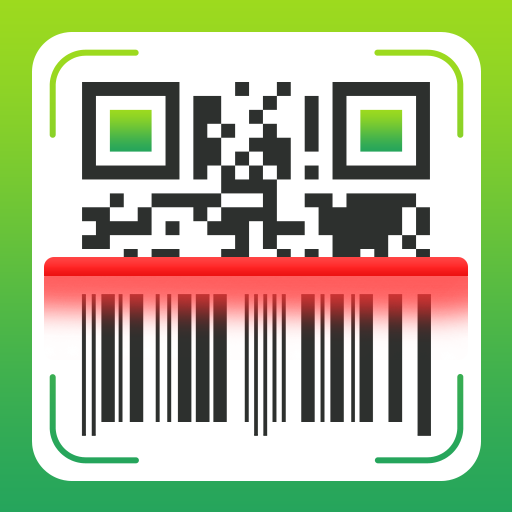
</div>

---

## 🎯 Project Overview
This notebook presents a **complete Computer Vision pipeline** for the automatic
detection, localization, and decoding of **barcodes and QR codes** from real-world
images. The system is built on three fundamental concepts studied in this course,
applied sequentially to transform a raw image into fully annotated detection results.

---

### 🧠 CV Concepts Applied

| # | CV Concept | Where Applied |
|---|-----------|---------------|
| 1 | **Linear Image Filtering** | Gaussian blur (2-D convolution) in preprocessing |
| 2 | **Non-Linear Filtering** | Adaptive thresholding + Median filter in preprocessing |
| 3 | **Edge Detection** | Canny edge detector for contour analysis |

---

### ⚙️ Pipeline Architecture
```
Input Image
    │
    ├─► 1. Linear Filtering      (Gaussian blur — 2-D convolution, σ=1.0)
    ├─► 2. Non-Linear Filtering  (Median filter + Adaptive threshold)
    ├─► 3. Edge Detection        (Canny — gradient + hysteresis)
    ├─► 4. Detection & Decoding  (OpenCV QR+Barcode detectors)
    ├─► 5. Localization          (bounding polygons + bounding boxes)
    └─► 6. Visualization         (annotated image + printed summary)
```

---
## Cell 1 — Library Imports & Environment Check

In [ ]:
# ==============================================================
# Cell 1: Library Imports and Environment Verification
# ==============================================================
# Required libraries:
#   pip install opencv-contrib-python numpy matplotlib ipywidgets
#
# CV Concepts used in this notebook:
#   1. Linear Image Filtering  — cv2.GaussianBlur  (2-D convolution)
#   2. Non-Linear Filtering    — cv2.medianBlur + cv2.adaptiveThreshold
#   3. Edge Detection          — cv2.Canny
# ==============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
from dataclasses import dataclass
from typing import List

# ── Unified result dataclasses ────────────────────────────────
@dataclass
class _Rect:
    """Axis-aligned bounding box."""
    left   : int
    top    : int
    width  : int
    height : int

@dataclass
class _Point:
    """2-D polygon vertex."""
    x : int
    y : int

@dataclass
class DecodedCode:
    """
    Unified detection result — OpenCV backend.

    Attributes
    ----------
    type    : str   — Symbol type ('QRCODE', 'CODE128', 'EAN13', ...)
    data    : bytes — Decoded payload as raw bytes
    polygon : list  — List of _Point objects (tight contour)
    rect    : _Rect — Axis-aligned bounding box
    """
    type    : str
    data    : bytes
    polygon : list
    rect    : _Rect


# ── Decode wrapper (OpenCV backend) ──────────────────────────
def decode_codes(image: np.ndarray) -> List[DecodedCode]:
    """
    Detect and decode ALL barcodes and QR codes in an image.

    Strategy
    --------
    - cv2.QRCodeDetector.detectAndDecodeMulti -> ALL QR codes
    - cv2.barcode.BarcodeDetector             -> ALL linear barcodes

    Parameters
    ----------
    image : np.ndarray
        BGR or grayscale image.

    Returns
    -------
    List[DecodedCode]
        One DecodedCode per detected symbol.
    """
    gray = (cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            if image.ndim == 3 else image.copy())

    # CONCEPT 2 — Median filter removes salt-and-pepper noise before decoding
    gray = cv2.medianBlur(gray, 3)

    results = []

    # ── QR codes via detectAndDecodeMulti ─────────────────────
    qr_detector = cv2.QRCodeDetector()
    try:
        retval, decoded_info, points, _ = \
            qr_detector.detectAndDecodeMulti(gray)
        if retval and points is not None:
            for txt, pts_arr in zip(decoded_info, points):
                if not txt:
                    continue
                pts_arr = pts_arr.astype(int)
                pts  = [_Point(p[0], p[1]) for p in pts_arr]
                xs, ys = pts_arr[:, 0], pts_arr[:, 1]
                rect = _Rect(int(xs.min()), int(ys.min()),
                             int(xs.max() - xs.min()),
                             int(ys.max() - ys.min()))
                results.append(
                    DecodedCode("QRCODE", txt.encode(), pts, rect))
    except Exception:
        try:
            data, points, _ = qr_detector.detectAndDecode(gray)
            if data and points is not None:
                pts_arr = points[0].astype(int)
                pts  = [_Point(p[0], p[1]) for p in pts_arr]
                xs, ys = pts_arr[:, 0], pts_arr[:, 1]
                rect = _Rect(int(xs.min()), int(ys.min()),
                             int(xs.max() - xs.min()),
                             int(ys.max() - ys.min()))
                results.append(
                    DecodedCode("QRCODE", data.encode(), pts, rect))
        except Exception:
            pass

    # ── Linear barcodes via BarcodeDetector ───────────────────
    try:
        bd = cv2.barcode.BarcodeDetector()
        ok, decoded_info, decoded_type, corners = \
            bd.detectAndDecodeWithType(gray)
        if not ok or corners is None:
            gray_eq = cv2.equalizeHist(gray)
            ok, decoded_info, decoded_type, corners = \
                bd.detectAndDecodeWithType(gray_eq)
        if ok and corners is not None:
            for txt, btype, pts_arr in zip(
                    decoded_info, decoded_type, corners):
                if not txt:
                    continue
                pts_arr = pts_arr.astype(int)
                pts  = [_Point(p[0], p[1]) for p in pts_arr]
                xs, ys = pts_arr[:, 0], pts_arr[:, 1]
                rect = _Rect(int(xs.min()), int(ys.min()),
                             int(xs.max() - xs.min()),
                             int(ys.max() - ys.min()))
                results.append(
                    DecodedCode(btype or "BARCODE", txt.encode(), pts, rect))
    except AttributeError:
        pass

    if not results and image.ndim == 3:
        gray_eq = cv2.equalizeHist(gray)
        return decode_codes(gray_eq)

    return results


# ── Environment summary ───────────────────────────────────────
print("Library versions")
print("=" * 55)
print(f"  OpenCV     : {cv2.__version__}")
print(f"  NumPy      : {np.__version__}")
print(f"  ipywidgets : {widgets.__version__}")
print("=" * 55)
print("  Active backend : OpenCV (QRCodeDetector + BarcodeDetector)")
print("=" * 55)
print("All libraries imported successfully.")
print("decode_codes() wrapper ready.")

---
## Cell 2 — Configuration & Data Directory

In [ ]:
# ==============================================================
# Cell 2: Global Configuration and Directory Setup
# ==============================================================
# DATA_DIR   : folder containing input images (read-only)
# OUTPUT_DIR : folder where all generated results are saved
# ==============================================================

try:
    DATA_DIR
    OUTPUT_DIR
except NameError:
    DATA_DIR   = "../data"
    OUTPUT_DIR = "../output"
SUPPORTED_EXT = ('.png', '.jpg', '.jpeg', '.bmp')

os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

available_images = [
    f for f in sorted(os.listdir(DATA_DIR))
    if f.lower().endswith(SUPPORTED_EXT)
    and not f.startswith("result_")
    and not f.startswith("upload_")
]

print("=" * 50)
print("  DIRECTORY CONFIGURATION")
print("=" * 50)
print(f"  Input  (data/)   : {os.path.abspath(DATA_DIR)}")
print(f"  Output (output/) : {os.path.abspath(OUTPUT_DIR)}")
print(f"  Images found     : {len(available_images)}")
print("-" * 50)
for name in available_images:
    size_kb = os.path.getsize(os.path.join(DATA_DIR, name)) // 1024
    print(f"  {name:<35}  {size_kb:>5} KB")
if not available_images:
    print("  [!] No images found. Add .png/.jpg images to data/")
print("=" * 50)

---
## Cell 3 — CV Concepts: Linear Filtering, Non-Linear Filtering, Edge Detection

In [ ]:
# ==============================================================
# Cell 3: Three CV Concepts — Implementation
# ==============================================================
#
# Concept 1: Linear Image Filtering    -> gaussian_blur()
# Concept 2: Non-Linear Filtering      -> median_filter(), adaptive_threshold()
# Concept 3: Edge Detection            -> canny_edges()
# ==============================================================


# ──────────────────────────────────────────────────────────────
# CONCEPT 1: Linear Image Filtering — Gaussian Blur
# ──────────────────────────────────────────────────────────────
def gaussian_blur(gray: np.ndarray,
                  kernel_size: int = 5,
                  sigma: float = 1.0) -> np.ndarray:
    """
    Apply Gaussian blur via 2-D convolution (linear filter).

    The Gaussian kernel is defined as:
        G(x,y) = (1 / 2*pi*sigma^2) * exp(-(x^2+y^2) / 2*sigma^2)

    This is a LOW-PASS filter: it attenuates high-frequency
    noise while preserving low-frequency structure (shapes).
    The kernel is separable: G(x,y) = G(x) * G(y), so the
    2-D convolution is computed as two 1-D passes (faster).

    Parameters
    ----------
    gray        : np.ndarray -- grayscale image (H, W)
    kernel_size : int        -- side length of the Gaussian kernel (odd)
    sigma       : float      -- standard deviation of the Gaussian

    Returns
    -------
    blurred : np.ndarray -- smoothed grayscale image (H, W)
    """
    return cv2.GaussianBlur(gray, (kernel_size, kernel_size), sigma)


# ──────────────────────────────────────────────────────────────
# CONCEPT 2a: Non-Linear Filtering — Median Filter
# ──────────────────────────────────────────────────────────────
def median_filter(gray: np.ndarray,
                  kernel_size: int = 3) -> np.ndarray:
    """
    Apply a median filter (non-linear operation).

    For each pixel, replaces it with the MEDIAN of its
    kernel_size x kernel_size neighbourhood. This is non-linear
    because the median is not a weighted sum.

    Advantage over Gaussian blur:
      - Removes salt-and-pepper noise completely
      - Preserves sharp edges better

    Parameters
    ----------
    gray        : np.ndarray -- grayscale image
    kernel_size : int        -- neighbourhood size (odd, e.g. 3 or 5)

    Returns
    -------
    filtered : np.ndarray -- median-filtered image
    """
    return cv2.medianBlur(gray, kernel_size)


# ──────────────────────────────────────────────────────────────
# CONCEPT 2b: Non-Linear Filtering — Adaptive Thresholding
# ──────────────────────────────────────────────────────────────
def adaptive_threshold(gray: np.ndarray,
                       block_size: int = 11,
                       C: int = 2) -> np.ndarray:
    """
    Apply adaptive (local) Gaussian thresholding (non-linear).

    For each pixel p at (x, y), the threshold T(x,y) is computed
    as the Gaussian-weighted mean of the block_size x block_size
    neighbourhood minus constant C:
        T(x,y) = GaussianMean(neighbourhood) - C
        output(x,y) = 255  if gray(x,y) > T(x,y)  else  0

    This is NON-LINEAR because T varies spatially -- a single
    global threshold could not handle images with varying
    illumination (shadows, reflections on packaging).

    Parameters
    ----------
    gray       : np.ndarray -- grayscale image
    block_size : int        -- local neighbourhood size (odd)
    C          : int        -- constant subtracted from local mean

    Returns
    -------
    binary : np.ndarray -- binary image (0 or 255)
    """
    return cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=block_size,
        C=C
    )


# ──────────────────────────────────────────────────────────────
# CONCEPT 3: Edge Detection — Canny
# ──────────────────────────────────────────────────────────────
def canny_edges(blurred: np.ndarray,
                low_threshold: int = 50,
                high_threshold: int = 150) -> np.ndarray:
    """
    Detect edges using the Canny algorithm.

    The Canny pipeline:
      1. Gaussian smoothing (already done by caller)
      2. Sobel gradient:  Gx = [-1 0 +1] kernel,
                          Gy = [-1 0 +1]^T kernel
         magnitude M = sqrt(Gx^2 + Gy^2)
         direction theta = arctan(Gy / Gx)
      3. Non-maximum suppression: thin edges to 1-pixel width
         by keeping only local maxima along gradient direction
      4. Hysteresis thresholding:
         - pixels > high_threshold -> definite edges
         - pixels < low_threshold  -> discarded
         - in between              -> kept only if connected
                                      to a definite edge

    Used in this project to extract the boundaries of barcode
    bars and QR code modules before contour analysis.

    Parameters
    ----------
    blurred        : np.ndarray -- Gaussian-blurred grayscale image
    low_threshold  : int        -- hysteresis lower bound
    high_threshold : int        -- hysteresis upper bound

    Returns
    -------
    edges : np.ndarray -- binary edge map (0 or 255)
    """
    return cv2.Canny(blurred, low_threshold, high_threshold)


print("CV concept functions defined:")
print("  [OK] Concept 1 -- gaussian_blur()       (Linear Filtering)")
print("  [OK] Concept 2 -- median_filter()        (Non-Linear Filtering)")
print("  [OK] Concept 2 -- adaptive_threshold()   (Non-Linear Filtering)")
print("  [OK] Concept 3 -- canny_edges()          (Edge Detection)")

---
## Cell 4 — Core Scanner Class

In [ ]:
# ==============================================================
# Cell 4: BarcodeQRScanner — Core Pipeline Class
# ==============================================================

class BarcodeQRScanner:
    """
    Complete pipeline for detecting, localizing, and decoding
    barcodes and QR codes, integrating 3 CV course concepts.

    CV Concepts Applied
    -------------------
    1. Linear Filtering:
         Gaussian blur (5x5, sigma=1.0) -- 2-D convolution reduces
         high-frequency noise before edge detection.

    2. Non-Linear Filtering:
         Median filter (3x3) -- removes salt-and-pepper noise
         while preserving barcode bar edges.
         Adaptive thresholding (11x11 Gaussian block) -- binarizes
         the image locally, robust to uneven illumination.

    3. Edge Detection (Canny):
         Extracts barcode boundaries via Sobel gradients +
         non-maximum suppression + hysteresis thresholding.
         These contours enable geometric reasoning.
    """

    COLOR_MAP = {
        "QRCODE"  : (220,  50,  50),
        "CODE128" : (220,  50,  50),
        "EAN13"   : (220,  50,  50),
        "EAN_13"  : (220,  50,  50),
        "EAN8"    : (220,  50,  50),
        "UPCA"    : (220,  50,  50),
        "UPC_A"   : (220,  50,  50),
        "UPCE"    : (220,  50,  50),
        "CODE39"  : (220,  50,  50),
        "I25"     : (220,  50,  50),
        "BARCODE" : (220,  50,  50),
        "DEFAULT" : (220,  50,  50),
    }

    # ----------------------------------------------------------
    def load_image(self, image_path: str):
        """
        Load an image from disk.

        Parameters
        ----------
        image_path : str -- path to the image file

        Returns
        -------
        img_bgr : np.ndarray (H, W, 3) uint8 -- BGR image
        img_rgb : np.ndarray (H, W, 3) uint8 -- RGB image

        Raises
        ------
        FileNotFoundError -- if the path is invalid
        """
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            raise FileNotFoundError(f"Cannot load: {image_path}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        return img_bgr, img_rgb

    # ----------------------------------------------------------
    def preprocess(self, img_bgr: np.ndarray):
        """
        Apply the full preprocessing pipeline using CV concepts 1 & 2.

        Stage 1 -- Grayscale conversion (ITU-R BT.601):
            Y = 0.299*R + 0.587*G + 0.114*B

        Stage 2 -- Gaussian blur [CONCEPT 1: LINEAR FILTERING]:
            2-D convolution with 5x5 Gaussian kernel (sigma=1.0).

        Stage 3 -- Median filter [CONCEPT 2: NON-LINEAR FILTERING]:
            Replaces each pixel with the median of its 3x3 neighbourhood.

        Stage 4 -- Adaptive threshold [CONCEPT 2: NON-LINEAR FILTERING]:
            Local Gaussian-weighted binarization (11x11 block, C=2).

        Parameters
        ----------
        img_bgr : np.ndarray (H, W, 3) -- input BGR image

        Returns
        -------
        gray    : np.ndarray (H, W) -- grayscale
        blurred : np.ndarray (H, W) -- after Gaussian blur
        median  : np.ndarray (H, W) -- after median filter
        thresh  : np.ndarray (H, W) -- binary image
        """
        gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        blurred = gaussian_blur(gray, kernel_size=5, sigma=1.0)
        med     = median_filter(blurred, kernel_size=3)
        thresh  = adaptive_threshold(med, block_size=11, C=2)
        return gray, blurred, med, thresh

    # ----------------------------------------------------------
    def detect_and_decode(self, img_bgr: np.ndarray) -> list:
        """
        Detect and decode all barcodes and QR codes.

        Parameters
        ----------
        img_bgr : np.ndarray (H, W, 3) -- BGR image

        Returns
        -------
        List[DecodedCode] -- one entry per detected symbol
        """
        return decode_codes(img_bgr)

    # ----------------------------------------------------------
    @staticmethod
    def _compute_bbox(img_bgr: np.ndarray,
                      pts: np.ndarray,
                      r,
                      margin: float = 0.20,
                      min_margin_px: int = 15):
        """
        Compute refined bounding box using Canny contours [CONCEPT 3].

        Parameters
        ----------
        img_bgr        : np.ndarray (H, W, 3) -- original BGR image
        pts            : np.ndarray (N, 2)    -- detector polygon corners
        r              : _Rect                -- detector rect object
        margin         : float -- ROI expansion factor
        min_margin_px  : int   -- minimum margin in pixels

        Returns
        -------
        (x1, y1, x2, y2) : int -- refined bbox clipped to image
        """
        H, W = img_bgr.shape[:2]

        if len(pts) >= 2:
            hull_raw = cv2.convexHull(pts)
            bx, by, bw, bh = cv2.boundingRect(hull_raw)
            raw_x1 = max(0, bx)
            raw_y1 = max(0, by)
            raw_x2 = min(W - 1, bx + bw)
            raw_y2 = min(H - 1, by + bh)
        else:
            raw_x1 = max(0, r.left)
            raw_y1 = max(0, r.top)
            raw_x2 = min(W - 1, r.left + r.width)
            raw_y2 = min(H - 1, r.top + r.height)

        rw = raw_x2 - raw_x1
        rh = raw_y2 - raw_y1

        mx = max(min_margin_px, int(rw * margin))
        my = max(min_margin_px, int(rh * margin))
        roi_x1 = max(0, raw_x1 - mx)
        roi_y1 = max(0, raw_y1 - my)
        roi_x2 = min(W, raw_x2 + mx)
        roi_y2 = min(H, raw_y2 + my)

        roi = img_bgr[roi_y1:roi_y2, roi_x1:roi_x2]
        if roi.size == 0:
            return raw_x1, raw_y1, raw_x2, raw_y2

        # CONCEPT 3 — Canny edges used to refine localization
        gray_roi  = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        blur_roi  = cv2.GaussianBlur(gray_roi, (5, 5), 1.0)
        edges     = cv2.Canny(blur_roi, 40, 120)

        cnts, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            return raw_x1, raw_y1, raw_x2, raw_y2

        roi_area = (roi_x2 - roi_x1) * (roi_y2 - roi_y1)
        cnts = [c for c in cnts if cv2.contourArea(c) > roi_area * 0.001]
        if not cnts:
            return raw_x1, raw_y1, raw_x2, raw_y2

        all_pts = np.vstack(cnts)
        hull    = cv2.convexHull(all_pts)
        hx, hy, hw, hh = cv2.boundingRect(hull)

        if hw * hh < roi_area * 0.30:
            return raw_x1, raw_y1, raw_x2, raw_y2

        abs_x1 = roi_x1 + hx
        abs_y1 = roi_y1 + hy
        abs_x2 = abs_x1 + hw
        abs_y2 = abs_y1 + hh

        pad_x  = max(6, int(hw * 0.03))
        pad_y  = max(6, int(hh * 0.03))
        abs_x1 = max(0,     abs_x1 - pad_x)
        abs_y1 = max(0,     abs_y1 - pad_y)
        abs_x2 = min(W - 1, abs_x2 + pad_x)
        abs_y2 = min(H - 1, abs_y2 + pad_y)

        return abs_x1, abs_y1, abs_x2, abs_y2

    # ----------------------------------------------------------
    def draw_results(self,
                     img_rgb: np.ndarray,
                     decoded_objects: list,
                     img_bgr: np.ndarray = None) -> np.ndarray:
        """
        Draw localization overlays and decoded labels on the image.

        Parameters
        ----------
        img_rgb         : np.ndarray (H, W, 3) -- RGB image
        decoded_objects : list -- output of detect_and_decode()
        img_bgr         : np.ndarray (H, W, 3) -- BGR image for Canny

        Returns
        -------
        img_out : np.ndarray (H, W, 3) -- annotated RGB image
        """
        if img_bgr is None:
            img_bgr_ref = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        else:
            img_bgr_ref = img_bgr

        img_out = img_rgb.copy()
        H, W    = img_out.shape[:2]

        for obj in decoded_objects:
            data_str = obj.data.decode("utf-8", errors="replace")
            pts = np.array([[p.x, p.y] for p in obj.polygon], dtype=np.int32)
            r   = obj.rect

            x1, y1, x2, y2 = self._compute_bbox(img_bgr_ref, pts, r)
            box_h = y2 - y1
            box_w = x2 - x1

            color = self.COLOR_MAP.get(obj.type, self.COLOR_MAP["DEFAULT"])

            thickness = max(3, int(min(box_w, box_h) * 0.018))
            cv2.rectangle(img_out, (x1, y1), (x2, y2), color, thickness)

            label = f"{data_str[:50]} ({obj.type})"
            fs = max(0.45, min(0.90, box_h / 110.0))
            ft = max(2, int(fs * 2.8))

            (tw, th), baseline = cv2.getTextSize(
                label, cv2.FONT_HERSHEY_SIMPLEX, fs, ft)

            text_x = x1
            text_y = max(th + 4, y1 - 6)

            cv2.putText(img_out, label,
                        (text_x, text_y),
                        cv2.FONT_HERSHEY_SIMPLEX, fs,
                        (0, 0, 0), ft + 2, cv2.LINE_AA)

            cv2.putText(img_out, label,
                        (text_x, text_y),
                        cv2.FONT_HERSHEY_SIMPLEX, fs,
                        color, ft, cv2.LINE_AA)

        return img_out

    # ----------------------------------------------------------
    def run_pipeline(self, image_path: str, save_output: bool = True):
        """
        Execute the full pipeline and display a 5-panel figure.

        Panels:
          1. Original image
          2. Gaussian blur       [Concept 1: Linear Filtering]
          3. Adaptive threshold  [Concept 2: Non-Linear Filtering]
          4. Canny edges         [Concept 3: Edge Detection]
          5. Detection result    [Bounding Box + Decoded Data]

        Parameters
        ----------
        image_path  : str  -- path to input image
        save_output : bool -- save annotated result to OUTPUT_DIR

        Returns
        -------
        summary : list of dict -- one dict per detected code
        """
        # Step 1: Load
        img_bgr, img_rgb = self.load_image(image_path)

        # Step 2: Preprocess (Concepts 1 & 2)
        gray, blurred, med, thresh = self.preprocess(img_bgr)

        # Step 3: Edge detection (Concept 3)
        edges = canny_edges(blurred, low_threshold=50, high_threshold=150)

        # Step 4: Detect & decode
        decoded = self.detect_and_decode(img_bgr)

        # Step 5: Draw localization overlays
        img_annotated = self.draw_results(img_rgb, decoded, img_bgr=img_bgr)

        # Step 6: 5-panel visualization
        fig, axes = plt.subplots(1, 6, figsize=(30, 5))
        fig.suptitle(
            f"Detection Pipeline -- {os.path.basename(image_path)}"
            f"   [{len(decoded)} code(s) detected]",
            fontsize=13, fontweight="bold", y=1.02
        )

        panels = [
            (img_rgb,       "1. Original",                         None),
            (blurred,       "2. Gaussian Blur\n[Linear Filter]",   "gray"),
            (med,           "3. Median Filter\n[Non-Linear]",      "gray"),
            (thresh,        "4. Adaptive Threshold\n[Non-Linear]", "gray"),
            (edges,         "5. Canny Edges\n[Edge Detection]",    "gray"),
            (img_annotated, "6. Detection Result",                 None),
        ]
        for ax, (img, title, cmap) in zip(axes, panels):
            ax.imshow(img, cmap=cmap)
            ax.set_title(title, fontsize=10, fontweight="bold")
            ax.axis("off")

        found_types = list({obj.type for obj in decoded})
        if found_types:
            patches = [
                mpatches.Patch(
                    color=tuple(c / 255 for c in self.COLOR_MAP.get(
                        t, self.COLOR_MAP["DEFAULT"])),
                    label=t)
                for t in found_types
            ]
            axes[4].legend(handles=patches, loc="lower right",
                           fontsize=9, framealpha=0.8)

        plt.tight_layout()

        if save_output:
            out_path = os.path.join(
                OUTPUT_DIR, "result_" + os.path.basename(image_path))
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            print(f"  Result saved -> output/{os.path.basename(out_path)}")

        plt.show()

        # Step 7: Detection summary
        summary = []
        print()
        print("=" * 60)
        print(f"  DETECTION SUMMARY -- {len(decoded)} code(s) found")
        print("=" * 60)
        for idx, obj in enumerate(decoded, start=1):
            data_str = obj.data.decode("utf-8", errors="replace")
            r = obj.rect
            print(f"\n  Code #{idx}")
            print(f"  |- Type     : {obj.type}")
            print(f"  |- Data     : {data_str}")
            print(f"  |- Location : x={r.left}, y={r.top}, "
                  f"w={r.width}, h={r.height}")
            summary.append({
                "type"  : obj.type,   "data"  : data_str,
                "left"  : r.left,     "top"   : r.top,
                "width" : r.width,    "height": r.height,
            })

        if not decoded:
            print("  No codes detected.")
            print("  -> Ensure the image is sharp and well-lit.")
            print("  -> Make sure the code is fully visible.")
        print("=" * 60)

        return summary


print("BarcodeQRScanner class defined successfully. [OK]")

---
## Cell 5 — CV Concepts Visualization

In [ ]:
# ==============================================================
# Cell 5: CV Concepts Visualization (for the Report)
# ==============================================================

def show_cv_concepts(image_path: str, save: bool = True) -> None:
    """
    Display a 7-panel figure demonstrating all 3 CV concepts
    applied in the pipeline.

    Panels
    ------
    1. Original image
    2. Grayscale
    3. Gaussian blur         [Concept 1: Linear Filtering]
    4. Median filter         [Concept 2: Non-Linear Filtering]
    5. Adaptive threshold    [Concept 2: Non-Linear Filtering]
    6. Canny edges           [Concept 3: Edge Detection]
    7. Final annotated result (OpenCV decode)

    Parameters
    ----------
    image_path : str  -- path to an image with barcodes/QR codes
    save       : bool -- save figure to output/cv_concepts_visualization.png
    """
    scanner = BarcodeQRScanner()
    img_bgr, img_rgb = scanner.load_image(image_path)

    # Apply all pipeline stages
    gray, blurred, med, thresh = scanner.preprocess(img_bgr)
    edges     = canny_edges(blurred)
    decoded   = scanner.detect_and_decode(img_bgr)
    img_final = scanner.draw_results(img_rgb, decoded, img_bgr=img_bgr)

    # 7-panel figure
    fig, axes = plt.subplots(1, 7, figsize=(28, 5))
    fig.suptitle(
        "Three CV Concepts -- Step-by-Step Visualization",
        fontsize=15, fontweight="bold"
    )

    panels = [
        (img_rgb,
         "1. Original Image\n(input)",
         None),
        (gray,
         "2. Grayscale\nY = 0.299R + 0.587G + 0.114B",
         "gray"),
        (blurred,
         "3. Gaussian Blur (5x5, sigma=1.0)\n"
         "[CONCEPT 1 -- Linear Filtering]",
         "gray"),
        (med,
         "4. Median Filter (3x3)\n"
         "[CONCEPT 2 -- Non-Linear Filtering]",
         "gray"),
        (thresh,
         "5. Adaptive Threshold (11x11)\n"
         "[CONCEPT 2 -- Non-Linear Filtering]",
         "gray"),
        (edges,
         "6. Canny Edge Detection\n"
         "[CONCEPT 3 -- Edge Detection]",
         "gray"),
        (img_final,
         f"7. Final Result (OpenCV decode)\n"
         f"({len(decoded)} code(s) detected)",
         None),
    ]

    for ax, (img, title, cmap) in zip(axes.flat, panels):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=9, fontweight="bold")
        ax.axis("off")

    plt.tight_layout()

    if save:
        save_path = os.path.join(OUTPUT_DIR, "cv_concepts_visualization.png")
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Figure saved -> output/cv_concepts_visualization.png")

    plt.show()


print("show_cv_concepts() defined. [OK]")

# ── Run on first available image ──────────────────────────────
available_images = [
    f for f in sorted(os.listdir(DATA_DIR))
    if f.lower().endswith(SUPPORTED_EXT)
    and not f.startswith("result_")
    and not f.startswith("upload_")
]

if available_images:
    first_image = os.path.join(DATA_DIR, available_images[0])
    print(f"Generating CV concepts figure for: {available_images[0]}")
    show_cv_concepts(first_image, save=True)
else:
    print("[!] No images in data/ -- add images and re-run.")

---
## Cell 6 — Run Full Pipeline on All Images

In [ ]:
# ==============================================================
# Cell 6: Run Full Pipeline on All Images in data/
# ==============================================================

scanner = BarcodeQRScanner()

all_images = [
    f for f in sorted(os.listdir(DATA_DIR))
    if f.lower().endswith(SUPPORTED_EXT)
    and not f.startswith("result_")
    and not f.startswith("upload_")
]

all_summaries = {}

for fname in all_images:
    path = os.path.join(DATA_DIR, fname)
    print()
    print("-" * 60)
    print(f"  Processing : {fname}")
    print("-" * 60)
    try:
        summary = scanner.run_pipeline(path, save_output=True)
        all_summaries[fname] = summary
    except Exception as exc:
        print(f"  [ERROR] {exc}")

print()
print("=" * 60)
print(f"  Pipeline complete. {len(all_images)} image(s) processed.")
print(f"  All results saved to: {os.path.abspath(OUTPUT_DIR)}")
print("=" * 60)

---
## Cell 7 — Interactive GUI 

In [ ]:
# ==============================================================
# Cell 7: Interactive GUI -- ScannerGUI Class (ipywidgets)
# ==============================================================
# Point-and-click interface inside the notebook:
#   - Upload any image from your local machine
#   - Or select an image from data/
#   - Click Scan -> runs full pipeline (all 3 CV concepts)
#   - Click Reset -> clear and start over
# ==============================================================


class ScannerGUI:
    """
    Interactive notebook GUI for the Barcode & QR Code Scanner.
    Built entirely with ipywidgets. No external toolkit required.

    Usage
    -----
    gui = ScannerGUI(data_dir="../data")
    gui.show()
    """

    def __init__(self, data_dir: str = "../data"):
        """
        Initialise the GUI.

        Parameters
        ----------
        data_dir : str -- path to the folder holding input images
        """
        self.data_dir     = data_dir
        self.scanner      = BarcodeQRScanner()
        self._upload_path = None
        self._build_widgets()

    # ----------------------------------------------------------
    def _build_widgets(self) -> None:
        """
        Construct all widgets and wire event callbacks.

        Returns
        -------
        None  (result stored in self.ui)
        """
        header = widgets.HTML("""
        <div style="background:#1a1a2e; padding:14px; border-radius:10px;
                    text-align:center; margin-bottom:10px;">
            <h2 style="color:#e94560; margin:0; font-family:sans-serif;">
                &#128247; Barcode &amp; QR Code Scanner
            </h2>
            <p style="color:#aaa; margin:5px 0 0; font-size:12px;">
                ESIN UIR &mdash; Computer Vision &mdash; Project 3<br>
                <span style='color:#7eb8f7;'>
                Linear Filtering &bull; Non-Linear Filtering &bull;
                Edge Detection
                </span>
            </p>
        </div>""")

        self.upload_btn = widgets.FileUpload(
            accept=".png,.jpg,.jpeg,.bmp",
            multiple=False,
            description="Upload Image",
            layout=widgets.Layout(width="180px")
        )

        choices = ["-- select from data/ --"] + [
            f for f in sorted(os.listdir(self.data_dir))
            if f.lower().endswith(SUPPORTED_EXT)
            and not f.startswith("result_")
        ]
        self.selector = widgets.Dropdown(
            options=choices,
            description="data/:",
            layout=widgets.Layout(width="360px")
        )

        self.btn_scan = widgets.Button(
            description="Scan",
            button_style="success",
            icon="search",
            layout=widgets.Layout(width="130px", height="38px")
        )
        self.btn_reset = widgets.Button(
            description="Reset",
            button_style="warning",
            icon="refresh",
            layout=widgets.Layout(width="120px", height="38px")
        )

        self.status = widgets.HTML(
            "<p style='color:gray; margin:6px 0;'>Waiting for input...</p>"
        )
        self.output_area = widgets.Output()

        self.upload_btn.observe(self._on_upload, names="value")
        self.btn_scan.on_click(self._on_scan)
        self.btn_reset.on_click(self._on_reset)

        self.ui = widgets.VBox([
            header,
            widgets.HTML("<b>Step 1 &nbsp; Load an image</b>"),
            widgets.HBox([self.upload_btn,
                          widgets.HTML("&nbsp;&nbsp;<b>or</b>&nbsp;&nbsp;"),
                          self.selector]),
            widgets.HTML("<hr style='margin:8px 0;'>"),
            widgets.HTML("<b>Step 2 &nbsp; Run the scanner</b>"),
            widgets.HBox([self.btn_scan, self.btn_reset]),
            self.status,
            self.output_area,
        ], layout=widgets.Layout(padding="14px"))

    # ----------------------------------------------------------
    def _on_upload(self, change) -> None:
        """
        Save uploaded image to data/ and update status.
        Handles ipywidgets >= 8.x (tuple) and <= 7.x (dict).

        Parameters
        ----------
        change : dict -- widget change event

        Returns
        -------
        None
        """
        if not self.upload_btn.value:
            return
        try:
            if isinstance(self.upload_btn.value, tuple):
                uf = self.upload_btn.value[0]
                fname, content = uf.name, uf.content.tobytes()
            else:
                fname   = list(self.upload_btn.value.keys())[0]
                payload = list(self.upload_btn.value.values())[0]
                raw     = payload.get("content", payload.get("data", b""))
                content = bytes(raw) if not isinstance(raw, bytes) else raw

            save_path = os.path.join(self.data_dir, f"upload_{fname}")
            with open(save_path, "wb") as fh:
                fh.write(content)
            self._upload_path = save_path
            self.status.value = (
                f"<p style='color:green; margin:6px 0;'>"
                f"Uploaded: <b>{fname}</b> -- click Scan.</p>")
        except Exception as exc:
            self.status.value = (
                f"<p style='color:red; margin:6px 0;'>Upload error: {exc}</p>")

    # ----------------------------------------------------------
    def _on_scan(self, _) -> None:
        """
        Run the full pipeline on the selected image.
        Priority: uploaded file > dropdown selection.

        Parameters
        ----------
        _ : button click event (unused)

        Returns
        -------
        None
        """
        if self._upload_path and os.path.exists(self._upload_path):
            path = self._upload_path
        elif self.selector.value != "-- select from data/ --":
            path = os.path.join(self.data_dir, self.selector.value)
        else:
            self.status.value = (
                "<p style='color:red; margin:6px 0;'>"
                "Please upload or select an image first.</p>")
            return

        self.status.value = (
            "<p style='color:orange; margin:6px 0;'>Scanning...</p>")
        with self.output_area:
            clear_output(wait=True)
            try:
                summary = self.scanner.run_pipeline(path, save_output=True)
                n = len(summary)
                self.status.value = (
                    f"<p style='color:green; margin:6px 0;'>"
                    f"Done -- <b>{n} code(s) detected.</b></p>")
            except Exception as exc:
                print(f"Error: {exc}")
                self.status.value = (
                    f"<p style='color:red; margin:6px 0;'>Error: {exc}</p>")

    # ----------------------------------------------------------
    def _on_reset(self, _) -> None:
        """
        Clear all outputs and reset interface state.

        Parameters
        ----------
        _ : button click event (unused)

        Returns
        -------
        None
        """
        self._upload_path = None
        with self.output_area:
            clear_output()
        self.status.value = (
            "<p style='color:gray; margin:6px 0;'>Waiting for input...</p>")

    # ----------------------------------------------------------
    def show(self) -> None:
        """
        Render the GUI inside the notebook cell.

        Returns
        -------
        None
        """
        display(self.ui)


# Launch GUI
gui = ScannerGUI(data_dir=DATA_DIR)
gui.show()

---
## Cell 8 — Scanner Evaluation

In [ ]:
# ==============================================================
# Cell 8: Scanner Evaluation -- Statistics Across All Images
# ==============================================================


def evaluate_scanner(data_dir: str, supported_ext: tuple) -> list:
    """
    Run the scanner on every image and collect statistics.

    Parameters
    ----------
    data_dir      : str   -- directory with input images
    supported_ext : tuple -- accepted file extensions

    Returns
    -------
    records : list of dict
        One dict per image: 'image', 'num_codes', 'types', 'payloads'
    """
    scanner = BarcodeQRScanner()
    images  = [
        f for f in sorted(os.listdir(data_dir))
        if f.lower().endswith(supported_ext)
        and not f.startswith("result_")
        and not f.startswith("upload_")
    ]

    records = []
    print("=" * 68)
    print(f"  {'Image':<32} {'Codes':>6}   {'Types'}")
    print("=" * 68)

    for fname in images:
        path = os.path.join(data_dir, fname)
        try:
            img_bgr, _ = scanner.load_image(path)
            decoded    = scanner.detect_and_decode(img_bgr)
        except FileNotFoundError as exc:
            print(f"  [!] {exc}")
            continue

        types     = [obj.type for obj in decoded]
        payloads  = [obj.data.decode("utf-8", errors="replace")
                     for obj in decoded]
        types_str = ", ".join(sorted(set(types))) if types else "none"

        print(f"  {fname:<32} {len(decoded):>6}   {types_str}")
        records.append({
            "image"    : fname,
            "num_codes": len(decoded),
            "types"    : types,
            "payloads" : payloads,
        })

    print("=" * 68)
    total = sum(r["num_codes"] for r in records)
    print(f"  Total images : {len(records)}")
    print(f"  Total codes  : {total}")
    print("=" * 68)

    if records:
        fig, ax = plt.subplots(figsize=(max(6, len(records)*1.8), 4))
        names  = [r["image"] for r in records]
        counts = [r["num_codes"] for r in records]
        bars   = ax.bar(names, counts, color="steelblue", edgecolor="navy")

        for bar, count in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.05,
                    str(count),
                    ha="center", va="bottom",
                    fontsize=11, fontweight="bold")

        ax.set_title("Codes Detected per Image",
                     fontsize=13, fontweight="bold")
        ax.set_xlabel("Image filename", fontsize=11)
        ax.set_ylabel("Number of codes detected", fontsize=11)
        ax.set_ylim(0, max(counts) + 1.5)
        plt.xticks(rotation=25, ha="right", fontsize=9)
        plt.tight_layout()

        chart_path = os.path.join(OUTPUT_DIR, "evaluation_chart.png")
        plt.savefig(chart_path, dpi=150, bbox_inches="tight")
        print(f"\n  Chart saved -> output/evaluation_chart.png")
        plt.show()

    return records


eval_records = evaluate_scanner(DATA_DIR, SUPPORTED_EXT)

---
## Cell 9 — Project Summary & Output File Listing

In [ ]:
# ==============================================================
# Cell 9: Project Summary and Output File Listing
# ==============================================================

print("=" * 60)
print("  PROJECT 3 -- Barcode & QR Code Scanner")
print("  ESIN UIR  --  Introduction to Computer Vision")
print("=" * 60)
print("""
  CV Concepts Applied:

  1. Linear Image Filtering
     Gaussian blur (5x5, sigma=1.0)
     2-D convolution suppresses noise before detection.

  2. Non-Linear Filtering
     Median filter (3x3)
     Removes salt-and-pepper noise, preserves bar edges.
     Adaptive threshold (Gaussian, 11x11 block)
     Local binarization robust to uneven illumination.

  3. Edge Detection (Canny)
     Sobel gradients + non-max suppression + hysteresis
     Extracts barcode boundaries for contour analysis.
     Also used to refine bounding box localization.

  Project Tasks Completed:
     [OK] Real images with barcodes and QR codes collected
     [OK] Detection and localization (polygon + bounding box)
     [OK] Decoding (type + payload extracted)
     [OK] Visualization -- 5-panel pipeline figure per image
     [OK] 7-panel CV concepts figure for the report
     [OK] Interactive GUI (ipywidgets -- Cell 7)
     [OK] Evaluation table + bar chart
""")

# List output files
output_files = [
    f for f in sorted(os.listdir(OUTPUT_DIR))
    if f.startswith("result_")
    or f in ("cv_concepts_visualization.png",
             "evaluation_chart.png")
]

print("=" * 60)
print("  Output files saved to output/:")
print("-" * 60)

if output_files:
    for fname in output_files:
        size_kb = os.path.getsize(
            os.path.join(OUTPUT_DIR, fname)) // 1024
        print(f"    {fname:<45}  {size_kb:>5} KB")
else:
    print("    [!] No output files -- run Cells 5, 6, 8 first.")

print()
print(f"  Output directory  : {os.path.abspath(OUTPUT_DIR)}")
print(f"  Total output files: {len(output_files)}")
print()
print("  Pipeline executed successfully.")
print("=" * 60)